<a href="https://colab.research.google.com/github/NataliiaHromyk/HomeWork_Python_DS/blob/main/Hromyk_%22HW_NLP_Classification_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("drive/MyDrive/ML_files/tweet_sentiment_train.csv.zip")

In [5]:
df.head(5)

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [6]:
df.info(verbose = True,  show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


Датафрейм складається із 4 текстових полів та 27481 рядків. Пусті значення присутні у двох полях по одній одиниці. Поле таргет(sentiment) має три значення

In [7]:
df['sentiment'].value_counts()

,count
sentiment,
neutral,11118
positive,8582
negative,7781


In [8]:
df.isnull().values.any()

np.True_

In [9]:
df[df.isnull().any(axis=1)]

,textID,text,selected_text,sentiment
314,fdb77c3752,NaN,NaN,neutral


In [10]:
df = df.dropna()

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [11]:
df['sentiment'].value_counts()

,count
sentiment,
neutral,11117
positive,8582
negative,7781


In [12]:
(df['sentiment'].value_counts(normalize = True).sort_values(ascending = False) * 100).head()

,proportion
sentiment,
neutral,40.454876
positive,31.229985
negative,28.315138


In [13]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns


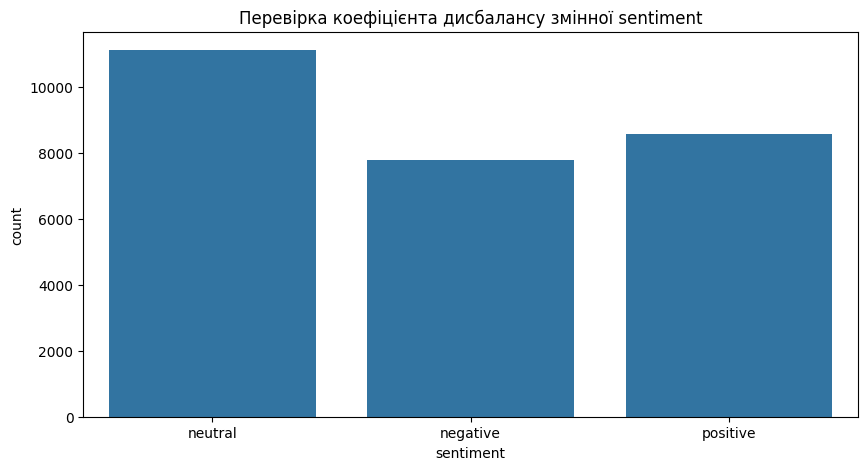

In [14]:
plt.figure(figsize = (10,5))
sns.countplot(x = df['sentiment'], data = df)
plt.title('Перевірка коефіцієнта дисбалансу змінної sentiment')
plt.show()

Таргет має три класи, які розподіленні +- рівномірно: до нейтрального відноситься 40% даних, до позитивного - 31%, до негативного - 28% даних

In [15]:
df['text_length'] = df['text'].str.len()

In [16]:
df['text_length'].describe()

,text_length
count,27480.000000
mean,68.330022
std,35.603870
min,3.000000
25%,39.000000
50%,64.000000
75%,97.000000
max,141.000000


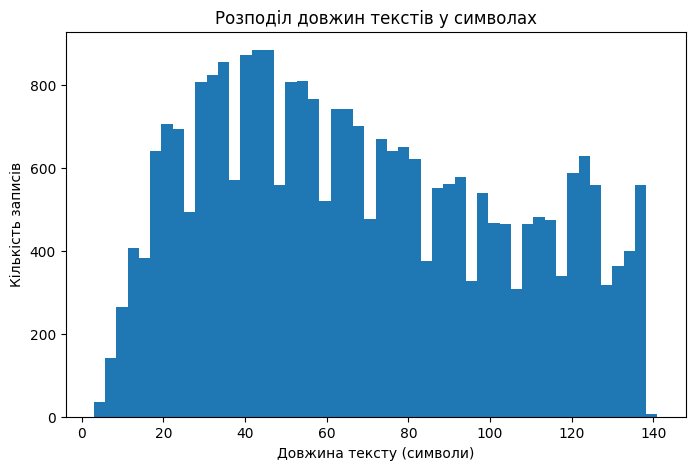

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['text_length'], bins=50)
plt.title('Розподіл довжин текстів у символах')
plt.xlabel('Довжина тексту (символи)')
plt.ylabel('Кількість записів')
plt.show()

Розподіл довжин між класами

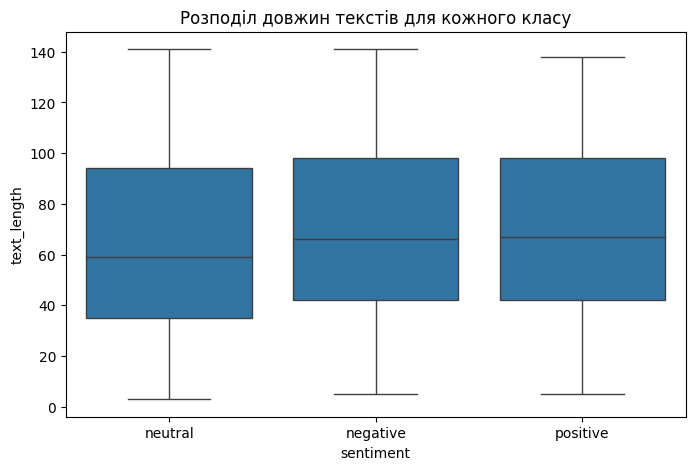

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='sentiment', y='text_length')
plt.title('Розподіл довжин текстів для кожного класу')
plt.show()

З гістограми видно, що більшість має довжину символів від 20 до 80 значень.
Медіана довжини постів становить 64 одиниці символів. Середеє значення незначно випереджає - становить 68 одиниць. Сильних викидів не спостерігається

Побудувавши боксплот - помітно, що нейтральні тексти мають меншу кількість символів, аніж негативні чи позитивні. Між негативними та позитивними різниці не помітно

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [19]:
import nltk

In [20]:
from nltk.tokenize import word_tokenize

In [21]:
from nltk.corpus import stopwords

In [22]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [23]:
english_stopwords = stopwords.words('english')

In [24]:
from nltk.stem.snowball import SnowballStemmer

In [25]:
stemmer = SnowballStemmer(language='english')

In [26]:
def tokenize(text):
    return [stemmer.stem(word) for word in word_tokenize(text)]

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

In [28]:
vectorizer = CountVectorizer(lowercase=True,
                             tokenizer=tokenize,
                             stop_words=english_stopwords)

In [29]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [30]:
%%time
vectorizer.fit(df.text)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


CPU times: user 8.83 s, sys: 6.93 ms, total: 8.84 s
Wall time: 9.04 s


CountVectorizer(stop_words=['a', 'about', 'above', 'after', 'again', 'against',
                            'ain', 'all', 'am', 'an', 'and', 'any', 'are',
                            'aren', "aren't", 'as', 'at', 'be', 'because',
                            'been', 'before', 'being', 'below', 'between',
                            'both', 'but', 'by', 'can', 'couldn', "couldn't", ...],
                tokenizer=<function tokenize at 0x7edd7f602980>)

In [31]:
len(vectorizer.vocabulary_)

23100

In [32]:
?CountVectorizer

In [33]:
vectorizer = CountVectorizer(lowercase=True,
                             tokenizer=tokenize,
                             stop_words=english_stopwords,
                             min_df=5,       # виключає слова, що зустрілись менше ніж у 5 документах
                             max_df=0.9,     # виключає слова, які зустрічаються у понад 90% документів
                             )

In [34]:
%%time
vectorizer.fit(df.text)

CPU times: user 7.98 s, sys: 20.9 ms, total: 8 s
Wall time: 8.13 s


CountVectorizer(max_df=0.9, min_df=5,
                stop_words=['a', 'about', 'above', 'after', 'again', 'against',
                            'ain', 'all', 'am', 'an', 'and', 'any', 'are',
                            'aren', "aren't", 'as', 'at', 'be', 'because',
                            'been', 'before', 'being', 'below', 'between',
                            'both', 'but', 'by', 'can', 'couldn', "couldn't", ...],
                tokenizer=<function tokenize at 0x7edd7f602980>)

In [35]:
len(vectorizer.vocabulary_)

3786

In [36]:
vectorizer.get_feature_names_out()[90:200]

array(['3rd', '4', '4.', '40', '400', '45', '4am', '4pm', '4th', '5',
       '50', '500', '5am', '5k', '5pm', '5th', '6', '60', '630', '6am',
       '6th', '7', '75', '7am', '7th', '8', '80', '8am', '8th', '9', '90',
       '99', '9am', '9th', ':', ':3', ';', '<', '=', '=/', '=d', '=o',
       '=p', '>', '?', '@', '[', '\\', ']', '^^', '_', '_127', '__', '_b',
       '_benson', '_c', '_carter', '_d', '_guy', '_henri', '_j', '_m',
       '_mari', '_ski', '_x', '_xo', '`', '``', 'a.m.', 'aaaah', 'aah',
       'ab', 'abandon', 'abbi', 'abil', 'abit', 'abl', 'abov', 'absolut',
       'abt', 'ac', 'academi', 'accept', 'access', 'accid', 'accident',
       'accomplish', 'accord', 'account', 'ace', 'ach', 'achiev', 'ack',
       'across', 'act', 'action', 'activ', 'actor', 'actress', 'actual',
       'ad', 'adam', 'add', 'addict', 'address', 'admir', 'admit',
       'adopt', 'ador', 'adult'], dtype=object)

In [37]:
%%time
inputs = vectorizer.transform(df.text)

CPU times: user 7.84 s, sys: 9.06 ms, total: 7.85 s
Wall time: 8.81 s


Заради унікальності і в майбутньому коректності даних - зробила обмеження по min_df та max_df, що  дозволило скоротити к-сть слів у словнику, витягнувиши ті слова, які точно повторюються у документах, але не в 90% значень

Таким чином вдалось скоротити словник з 23100 слів до 3786.

Ще одним варіантом було - підставяти різні значення max_features та в майбутньому розраховувати якість моделі. Порівнявши якості - обрати потрібну к-сть слів у словнику

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [38]:
df['sentiment'].value_counts()

,count
sentiment,
neutral,11117
positive,8582
negative,7781


In [39]:
df['sentiment'] = df.sentiment.map({'negative': -1, 'neutral': 0,'positive': 1})

In [40]:
df['sentiment'].value_counts()

,count
sentiment,
0,11117
1,8582
-1,7781


In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(inputs, df.sentiment,
                                                            test_size=0.3, random_state=42)

In [43]:
X_train_bow.shape, X_test_bow.shape

((19236, 3786), (8244, 3786))

#####Навчання моделі логістичної регресії

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
model_log_reg = LogisticRegression(solver='liblinear',multi_class='ovr')

In [46]:
%%time
model_log_reg.fit(X_train_bow, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 550 ms, sys: 2.8 ms, total: 553 ms
Wall time: 557 ms


LogisticRegression(multi_class='ovr', solver='liblinear')

In [47]:
train_preds_lg = model_log_reg.predict(X_train_bow)
test_preds_lg = model_log_reg.predict(X_test_bow)

In [48]:
pd.Series(train_preds_lg).value_counts()

,count
0,8486
1,5900
-1,4850


In [49]:
from sklearn.metrics import accuracy_score, f1_score

In [50]:
accuracy_score(y_train, train_preds_lg)

0.7981389062175088

In [51]:
from sklearn.metrics import classification_report

In [52]:
print(classification_report(y_train, train_preds_lg))

              precision    recall  f1-score   support

          -1       0.83      0.74      0.78      5425
           0       0.76      0.82      0.79      7774
           1       0.83      0.82      0.82      6037

    accuracy                           0.80     19236
   macro avg       0.81      0.79      0.80     19236
weighted avg       0.80      0.80      0.80     19236



In [53]:
from sklearn.metrics import roc_auc_score

def auc_roc_multiclass(model):
    # Отримуємо передбачені ймовірності для всіх класів
    y_train_proba = model.predict_proba(X_train_bow)
    y_test_proba = model.predict_proba(X_test_bow)

    # Обчислюємо AUC-ROC з урахуванням усіх класів (one-vs-rest)
    auc_roc_train = roc_auc_score(y_train, y_train_proba, multi_class='ovr')
    auc_roc_test = roc_auc_score(y_test, y_test_proba, multi_class='ovr')

    print(f'AUROC for Train: {auc_roc_train:.2f}')
    print(f'AUROC for Test: {auc_roc_test:.2f}')

In [54]:
auc_roc_multiclass(model_log_reg)

AUROC for Train: 0.92
AUROC for Test: 0.83


#####Decision Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier

In [56]:
model_dt = DecisionTreeClassifier(random_state=42)

In [57]:
%%time
model_dt.fit(X_train_bow, y_train)

CPU times: user 5.32 s, sys: 2.52 ms, total: 5.32 s
Wall time: 5.38 s


DecisionTreeClassifier(random_state=42)

In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import pandas as pd

def tree_metrics(max_depth, max_leaf_nodes):
    model_dt = DecisionTreeClassifier(
        max_depth=max_depth,
        max_leaf_nodes=max_leaf_nodes,
        random_state=42
    )
    model_dt.fit(X_train_bow, y_train)

    train_error = 1 - model_dt.score(X_train_bow, y_train)
    val_error = 1 - model_dt.score(X_test_bow, y_test)

    train_pred = model_dt.predict_proba(X_train_bow)
    val_pred = model_dt.predict_proba(X_test_bow)

    train_auc = roc_auc_score(y_train, train_pred, multi_class='ovr')
    val_auc = roc_auc_score(y_test, val_pred, multi_class='ovr')

    return {
        'Max Depth': max_depth,
        'Max Leaf Nodes': max_leaf_nodes,
        'Training Error': train_error,
        'Validation Error': val_error,
        'Train AUC': train_auc,
        'Val AUC': val_auc
    }


results = []

for depth in range(2, 20):
    for leaf in range(2, 50):
        res = tree_metrics(depth, leaf)
        results.append(res)

# Створюємо датафрейм
stats_tree = pd.DataFrame(results)

In [59]:
stats_tree.loc[stats_tree['Val AUC'].idxmax()]

,860
Max Depth,19.000000
Max Leaf Nodes,46.000000
Training Error,0.371283
Validation Error,0.378214
Train AUC,0.739068
Val AUC,0.732949


Із результатів показників аук спостерігаємо, що логістична модель демонструє кращі показники конверсії

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [66]:
#model_log_reg.coef_.T - транспонуємо для розрахунку коефіцієнтів
feature_importance_df = pd.DataFrame(model_log_reg.coef_.T, index=vectorizer.get_feature_names_out(), columns=model_log_reg.classes_)

#додамо колонку з найбільшим впливом за абсолютним значенням
feature_importance_df["max_abs_impact"] = feature_importance_df.abs().max(axis=1)

#сортуємо за впливом
feature_importance_df.sort_values("max_abs_impact", ascending=False).head(30)

,-1,0,1,max_abs_impact
awesom,-3.067389,-1.650301,3.279549,3.279549
thank,-2.666356,-1.850914,3.198762,3.198762
sad,2.991036,-1.502024,-3.103031,3.103031
cute,-2.258735,-1.439604,3.062191,3.062191
suck,2.989243,-1.519856,-2.813266,2.989243
bore,2.896303,-1.595771,-2.440653,2.896303
shame,1.904141,0.005717,-2.863571,2.863571
amaz,-2.139076,-1.587560,2.839387,2.839387
nice,-1.851859,-1.575102,2.769556,2.769556
excit,-1.367127,-1.495632,2.757514,2.757514


О так, дана модель логічно демонструє чому ті чи інші слова відносяться до позитивних, негативних чи нейтральних. І помітна протилежна залежність від позитивного до негативного значення. Тоді як нейтральне займає посередню роль зазвичай. Для прикладу ось ці слова збільшують ймовірність, що текст являється позитивним: awesom, thank, cute, amaz - відповідно для нейтральних вони протилежно залежні, що цілком логічно

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [71]:
?TfidfVectorizer

In [82]:
vectorizer_tf = TfidfVectorizer(lowercase=True,
                                tokenizer=tokenize,
                                stop_words=english_stopwords,
                                min_df=5,       # виключає слова, що зустрілись менше ніж у 5 документах
                                max_df=0.9,     # виключає слова, які зустрічаються у понад 90% документів
                                )

In [95]:
%%time
vectorizer_tf.fit(df.text)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


CPU times: user 8.35 s, sys: 18.8 ms, total: 8.37 s
Wall time: 8.47 s


TfidfVectorizer(max_df=0.9, min_df=5,
                stop_words=['a', 'about', 'above', 'after', 'again', 'against',
                            'ain', 'all', 'am', 'an', 'and', 'any', 'are',
                            'aren', "aren't", 'as', 'at', 'be', 'because',
                            'been', 'before', 'being', 'below', 'between',
                            'both', 'but', 'by', 'can', 'couldn', "couldn't", ...],
                tokenizer=<function tokenize at 0x7edd7f602980>)

In [90]:
len(vectorizer_tf.vocabulary_)

3786

In [96]:
inputs_tf = vectorizer_tf.transform(df.text)

In [97]:
#в train_test_split нічого не змінювала в розбитті параметрів, відповідно, індекси залишились ті самі - дані ідентично розбитті як і в попередньому варіанті
X_train_tf, X_test_tf, y_train, y_test = train_test_split(inputs_tf, df.sentiment,
                                                          test_size=0.3, random_state=42)

In [98]:
model_log_reg_tf = LogisticRegression(solver='liblinear',multi_class='ovr')

In [100]:
%%time
model_log_reg_tf.fit(X_train_tf, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 282 ms, sys: 992 µs, total: 283 ms
Wall time: 291 ms


LogisticRegression(multi_class='ovr', solver='liblinear')

In [107]:
train_preds_lg_tf = model_log_reg_tf.predict(X_train_tf)
test_preds_lg_tf = model_log_reg_tf.predict(X_test_tf)

In [108]:
print(classification_report(y_test, test_preds_lg_tf))

              precision    recall  f1-score   support

          -1       0.72      0.57      0.64      2356
           0       0.63      0.76      0.69      3343
           1       0.76      0.71      0.74      2545

    accuracy                           0.69      8244
   macro avg       0.70      0.68      0.69      8244
weighted avg       0.70      0.69      0.69      8244



In [113]:
# Отримуємо передбачені ймовірності для всіх класів
y_train_proba_tf = model_log_reg_tf.predict_proba(X_train_tf)
y_test_proba_tf = model_log_reg_tf.predict_proba(X_test_tf)

# Обчислюємо AUC-ROC з урахуванням усіх класів (one-vs-rest)
auc_roc_train_tf = roc_auc_score(y_train, y_train_proba_tf, multi_class='ovr')
auc_roc_test_tf = roc_auc_score(y_test, y_test_proba_tf, multi_class='ovr')

print(f'AUROC for Train: {auc_roc_train_tf:.2f}')
print(f'AUROC for Test: {auc_roc_test_tf:.2f}')

AUROC for Train: 0.90
AUROC for Test: 0.84


In [118]:
#model_log_reg.coef_.T - транспонуємо для розрахунку коефіцієнтів
feature_importance_df_tf = pd.DataFrame(model_log_reg_tf.coef_.T, index=vectorizer_tf.get_feature_names_out(), columns=model_log_reg_tf.classes_)

#додамо колонку з найбільшим впливом за абсолютним значенням
feature_importance_df_tf["max_abs_impact"] = feature_importance_df_tf.abs().max(axis=1)

#сортуємо за впливом
feature_importance_df_tf.sort_values("max_abs_impact", ascending=False).head(30)

,-1,0,1,max_abs_impact
love,-6.143005,-4.481515,8.277733,8.277733
thank,-5.455709,-4.934804,7.753116,7.753116
miss,6.925835,-3.384516,-5.487592,6.925835
sad,6.829253,-3.922738,-5.052395,6.829253
happi,-3.053181,-5.031288,6.579393,6.579393
great,-3.829640,-4.120854,6.511158,6.511158
awesom,-4.433249,-3.643069,6.463460,6.463460
good,-2.860084,-4.149717,6.270273,6.270273
nice,-3.378789,-3.969630,6.132369,6.132369
suck,5.873127,-3.451725,-3.944463,5.873127


Токени у даному розподіленні відрізняються і це відбулось за рахунок того, що при TF-IDF враховується наскільки популярне це слово в тексті та тотально по всім текстам навченої моделі.Я би використовувала модель TF-IDF, оскільки і показник АУК на тестових даних продемонстрував на 1% кращі показники порівнянно із моделею логістичної регресії по даних BOW

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [122]:
df['prediction'] = model_log_reg_tf.predict(inputs_tf)

In [123]:
df.head()

,textID,text,selected_text,sentiment,text_length,prediction
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",0,36,0
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,-1,46,-1
2,088c60f138,my boss is bullying me...,bullying me,-1,25,0
3,9642c003ef,what interview! leave me alone,leave me alone,-1,31,0
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",-1,75,-1


In [124]:
from sklearn.metrics import confusion_matrix

In [125]:
confusion_matrix(df.sentiment, df.prediction)

array([[5001, 2337,  443],
       [1117, 8822, 1178],
       [ 318, 1883, 6381]])

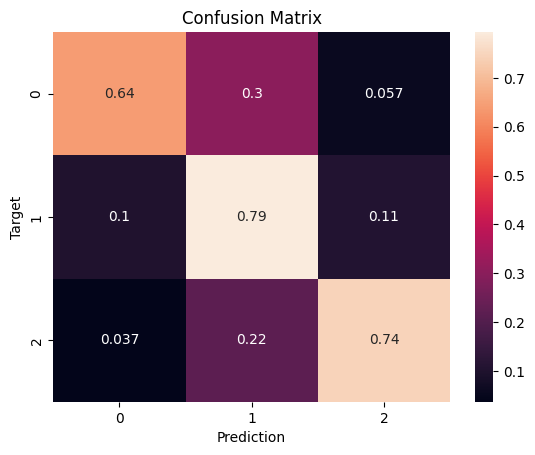

In [127]:
cf = confusion_matrix(df.sentiment, df.prediction, normalize='true')
plt.figure()
sns.heatmap(cf, annot=True)
plt.xlabel('Prediction')
plt.ylabel('Target')
plt.title('Confusion Matrix');

Клас 0 (негативний) має найбільшу кількість плутанини (часто помилково відносять до нейтрального). Дуже мала доля, де позитивний клас плутається з негативним (чи навпаки).

In [131]:
df[df['sentiment']!=df['prediction']]

,textID,text,selected_text,sentiment,text_length,prediction
2,088c60f138,my boss is bullying me...,bullying me,-1,25,0
3,9642c003ef,what interview! leave me alone,leave me alone,-1,31,0
5,28b57f3990,http://www.dothebouncy.com/smf - some shameles...,http://www.dothebouncy.com/smf - some shameles...,0,92,1
10,2339a9b08b,"as much as i love to be hopeful, i reckon the...","as much as i love to be hopeful, i reckon the ...",0,107,1
12,74a76f6e0a,My Sharpie is running DANGERously low on ink,DANGERously,-1,44,0
...,...,...,...,...,...,...
27472,8f5adc47ec,http://twitpic.com/663vr - Wanted to visit the...,were too late,-1,75,0
27474,8f14bb2715,So I get up early and I feel good about the da...,I feel good ab,1,126,0
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",-1,122,0
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,1,27,-1


Модель плутає:
* саркастичні або непрямі негативні висловлювання DANGERously low on ink
* короткі тексти без чітких маркерів настрою  leave me alone
* тексти з подвійними емоціями as much as I love to be hopeful

З поліпшення пропоную:
* використати лематизацію замість стемінгу, що допоможе зберегти корінні форми слів
* видалити юрл, зайві символи, що дають шум
* замінити логістичну модель на більш потужнішу

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model